# Social XR Motion Analysis: Social Synchrony, Hand Synchrony, Proxemics

A **format-agnostic** version of the dyadic head-motion analysis: point it at
any social-XR session -- regardless of which export format it came from --
and it runs the same synchrony/proxemics pipeline over however many
participants that session has (2, 3, 7, ...).

**Supported formats** (see `../lib/xr_loaders.py` for the full spec of each):

| format | example | layout | rotation | hands | voice |
|---|---|---|---|---|---|
| `position_rotation_csv` | `8-1_position_rotation.csv` + `8-2_position_rotation.csv` | one file per participant | Euler | yes | no |
| `quest_csv` | `Experiment1_30Hz_Quest.csv` | one file, whole session | quaternion | no | no |
| `pkl_long` | `H01_H02_fashion_xzy.pkl`, `conflab_ep02_4_33_42.pkl` | one file, whole session | (position + facing vector only) | no | yes (conflab) |

Every format is normalized on load into one **unified long-format schema**
(`participant_id`, `t_s`, `position_x/y/z`, `rotation_x/y/z`, hand
position/rotation, voice-activity flags -- NaN wherever a format doesn't
carry that signal). All analyses below run against that unified schema, so
they never need to know which format a session came from.

**This notebook:**
1. Loads a chosen session via `xr_loaders.load_session(...)`.
2. Resamples every participant onto a shared uniform time grid (solves
   cross-participant time alignment for free).
3. Runs three analyses, generalized to **all pairs** of participants:
   - **Social synchrony (aggregate direction-sync score)** -- per-pair,
     not windowed: frame-to-frame delta of each person's facing-direction
     vector, Pearson-correlated per axis and summed.
   - **Hand-movement synchrony** -- windowed Pearson correlation of
     frame-to-frame combined left/right hand motion between each pair,
     normalized to [0, 1]. Automatically skipped for participants/formats
     without hand tracking.
   - **Proxemics** -- pairwise 3D distance between every pair over time, with
     Hall's proxemic zone breakdown (intimate / personal / social / public).
4. Runs the whole pipeline across **all four example datasets** in one pass
   and prints a comparison table, to demonstrate that the same code path
   handles every format.

To add your own dataset: drop the file(s) in `../Data/`, add an entry to
`DATASETS` in the config cell below (or call `load_session` directly with
the right `paths=`), and re-run.

## 1. Imports & configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, str(Path('../lib').resolve()))
from xr_loaders import load_session, UNIFIED_COLUMNS
from xr_analysis import (
    resample_session, estimate_native_hz, has_hand_data, has_direction_data,
    direction_sync_all_pairs, hand_synchrony,
    compute_proxemics, zone_breakdown, pair_summary_matrix, all_pairs,
)
from xr_groups import plot_sync_score_boxplot

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

DATA_DIR = Path('../Data')
SYNC_WINDOW_S = 1.0       # window length for hand synchrony
PROXEMICS_HZ = 1.0        # proxemics doesn't need tracking-rate precision

PURPLE, ORANGE, BLUE, RED = '#7b6bd6', '#e08a3c', '#3b6fb6', '#c0392b'

# Registry of example sessions. `paths` is a single file for self-contained
# formats, or a list of one-file-per-participant files for position_rotation_csv.
DATASETS = {
    'dyad_position_rotation': dict(
        paths=[DATA_DIR / '8-1_position_rotation.csv', DATA_DIR / '8-2_position_rotation.csv']),
    'quest_7person':          dict(paths=DATA_DIR / 'quest_csv' / 'Experiment1_30Hz_Quest.csv'),
    'fashion_pkl':            dict(paths=DATA_DIR / 'pkl' / 'H01_H02_fashion_xzy.pkl'),
    'conflab_pkl':            dict(paths=DATA_DIR / 'pkl' / 'conflab_ep02_4_33_42.pkl'),
}

# <<< Choose which dataset to run through the detailed, plotted pipeline below.
SELECTED = 'dyad_position_rotation'

## 2. Load the selected session

`load_session` auto-detects the format from the file(s) and returns the
unified schema -- same columns regardless of source.

In [2]:
df = load_session(**DATASETS[SELECTED], session_id=SELECTED)
participants = sorted(df['participant_id'].unique())
native_hz = estimate_native_hz(df)

print(f"Dataset: {SELECTED}  |  format: {df['source_format'].iloc[0]}")
print(f"Participants ({len(participants)}): {participants}")
print(f"Rows: {len(df)}  |  estimated native rate: {native_hz:.1f} Hz")
print(f"Duration: {(df['t_s'].max() - df['t_s'].min()):.1f} s")
df.head()

Dataset: dyad_position_rotation  |  format: position_rotation_csv
Participants (2): ['1', '2']
Rows: 57307  |  estimated native rate: 29.0 Hz
Duration: 1003.8 s


,session_id,source_format,participant_id,t_s,position_x,position_y,position_z,rotation_x,rotation_y,rotation_z,left_hand_position_x,left_hand_position_y,left_hand_position_z,right_hand_position_x,right_hand_position_y,right_hand_position_z,left_hand_rotation_x,left_hand_rotation_y,left_hand_rotation_z,right_hand_rotation_x,right_hand_rotation_y,right_hand_rotation_z,is_speaking,is_muted
0,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360913,-2.414660,0.988270,358.5654,84.09101,215.6122,-5.222950,-2.193258,0.330182,NaN,NaN,NaN,357.2315,265.3522,149.1852,NaN,NaN,NaN,NaN,NaN
1,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360918,-2.414667,0.988270,358.5660,84.09113,215.6089,-5.222950,-2.193258,0.330182,-5.521457,-2.602808,0.337104,357.2315,265.3522,149.1852,359.4841,76.37319,284.4571,NaN,NaN
2,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360923,-2.414672,0.988271,358.5677,84.09110,215.6115,-5.222958,-2.193269,0.330193,-5.521466,-2.602815,0.337092,357.2316,265.3522,149.1819,359.4841,76.37308,284.4536,NaN,NaN
3,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360923,-2.414673,0.988270,358.5679,84.09112,215.6119,-5.222944,-2.193279,0.330198,-5.521479,-2.602810,0.337089,357.2316,265.3522,149.1850,359.4841,76.37312,284.4568,NaN,NaN
4,dyad_position_rotation,position_rotation_csv,1,1.782307e+09,-5.360909,-2.414673,0.988267,358.5640,84.09491,215.6145,-5.222931,-2.193292,0.330195,-5.521479,-2.602810,0.337089,357.2316,265.3523,149.1878,359.4841,76.37312,284.4568,NaN,NaN


## 3. Resample onto a shared time grid

Every participant's position (and hand position, where tracked) is linearly
interpolated onto one shared uniform grid spanning the overlap of all
participants' tracked time. This is generalized to any number of
participants -- a 7-person Quest session and a 2-person dyad go through the
identical resampling call.

Two grids: the session's native rate (rounded) for motion-based synchrony,
and a fixed 1 Hz grid for proxemics (distance doesn't need tracking-rate
precision, and 1 Hz keeps zone-percentage counting simple).

In [3]:
ANALYSIS_HZ = round(native_hz)
resampled = resample_session(df, rate_hz=ANALYSIS_HZ)
resampled_1hz = resample_session(df, rate_hz=PROXEMICS_HZ)

hand_tracked = [p for p in participants if has_hand_data(resampled[p])]
print(f"Analysis grid: {ANALYSIS_HZ} Hz, {len(resampled[participants[0]])} rows/participant")
print(f"Proxemics grid: {PROXEMICS_HZ} Hz, {len(resampled_1hz[participants[0]])} rows/participant")
print(f"Participants with hand tracking: {hand_tracked or 'none'}")
resampled[participants[0]].head()

Analysis grid: 29 Hz, 29109 rows/participant
Proxemics grid: 1.0 Hz, 1004 rows/participant
Participants with hand tracking: ['1', '2']


,t_s,position_x,position_y,position_z,left_hand_position_x,left_hand_position_y,left_hand_position_z,right_hand_position_x,right_hand_position_y,right_hand_position_z,session_time_s
0,1.782307e+09,-5.360914,-2.414662,0.988270,-5.222950,-2.193258,0.330182,-5.521457,-2.602808,0.337104,0.000000
1,1.782307e+09,-5.360919,-2.414668,0.988270,-5.222952,-2.193261,0.330185,-5.521459,-2.602810,0.337101,0.034483
2,1.782307e+09,-5.360923,-2.414672,0.988270,-5.222954,-2.193272,0.330195,-5.521469,-2.602814,0.337091,0.068965
3,1.782307e+09,-5.360920,-2.414673,0.988269,-5.222941,-2.193282,0.330197,-5.521479,-2.602810,0.337089,0.103448
4,1.782307e+09,-5.360910,-2.414675,0.988267,-5.222938,-2.193284,0.330193,-5.521481,-2.602808,0.337090,0.137931


## 4. Social synchrony (aggregate direction-sync score)

One score per pair (not windowed): align the pair on the shared time grid,
take the frame-to-frame delta of each person's **facing-direction** vector
(not position), and Pearson-correlate the two people's delta series on each
axis. `corr_agg` sums whichever axes carry real signal (some formats only
track a floor-plane facing direction, so a structurally-constant axis is
skipped rather than forcing the whole score to NaN). Requires a facing
direction vector, which `position_rotation_csv` doesn't carry -- that
session reports "n/a" below, same pattern as the hand-synchrony skip in
section 6.

In [1]:
direction_tracked = [p for p in participants if has_direction_data(resampled[p])]
if len(direction_tracked) < 2:
    print(f"Social synchrony (aggregate direction-sync score): skipped -- fewer than 2 participants with "
          f"facing-direction data in this session/format ({direction_tracked or 'none tracked'}).")
    direction_sync = pd.DataFrame(columns=['participant_a', 'participant_b', 'corr_agg', 'corr_x', 'corr_y', 'corr_z', 'n_frames'])
else:
    direction_sync = direction_sync_all_pairs(resampled)
    print(f"Direction-tracked participants: {direction_tracked}")
    print(f"Mean aggregate direction-sync score: {direction_sync['corr_agg'].mean():.3f}")
direction_sync

Social synchrony (aggregate direction-sync score): skipped -- fewer than 2 participants with facing-direction data in this session/format (none tracked).


Empty DataFrame
Columns: [participant_a, participant_b, corr_agg, corr_x, corr_y, corr_z, n_frames]
Index: []

In [1]:
# --- Plot: aggregate direction-sync score by pair ---
if len(direction_sync):
    pair_labels = [f'{pa}-{pb}' for pa, pb in all_pairs(direction_tracked)]
    data_by_pair = {lab: direction_sync.loc[(direction_sync.participant_a == pa) & (direction_sync.participant_b == pb), 'corr_agg'].to_numpy()
                     for lab, (pa, pb) in zip(pair_labels, all_pairs(direction_tracked))}
    fig, ax = plt.subplots(figsize=(max(5.5, 1.3 * len(data_by_pair)), 5.5))
    plot_sync_score_boxplot(ax, data_by_pair, f'Social Synchrony (Aggregate Direction-Sync) by Pair -- {SELECTED}',
                             rotate_labels=len(data_by_pair) > 3)
    plt.tight_layout()
    plt.savefig(f'social_synchrony_{SELECTED}.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No plot -- no facing-direction data available for this format/session.")

No plot -- no facing-direction data available for this format/session.


## 5. Hand-movement synchrony

Windowed (1s) Pearson correlation of frame-to-frame combined left/right
hand-speed between each pair, normalized to [0, 1]. Only meaningful for formats
that carry hand tracking (`position_rotation_csv` in the examples here) --
for everyone else this section reports that no hand data was available and
moves on, rather than erroring.

Hand-tracked participants: ['1', '2']
Mean hand synchrony: 0.5133  (0.5 = chance)


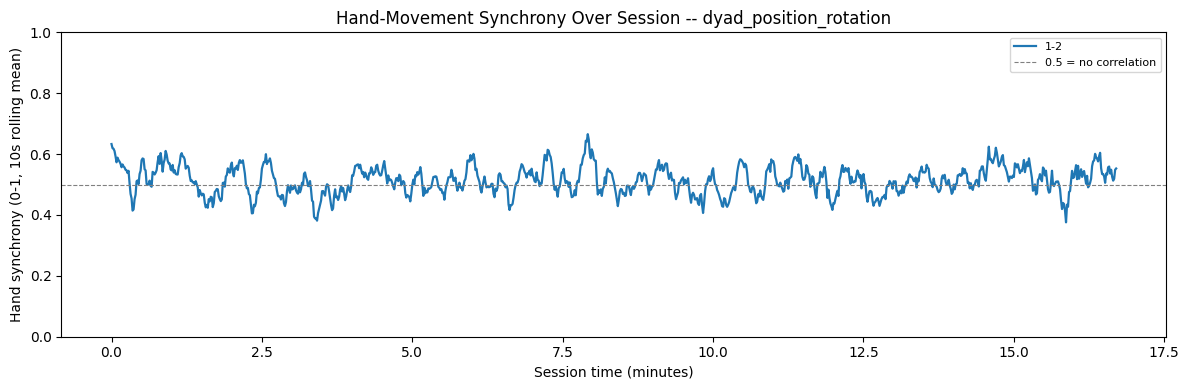

In [8]:
if len(hand_tracked) < 2:
    print(f"Hand-movement synchrony: skipped -- fewer than 2 participants with hand "
          f"tracking in this session/format ({hand_tracked or 'none tracked'}).")
    hand_sync = pd.DataFrame(columns=['participant_a', 'participant_b', 'session_time_s', 'pearson_r', 'synchrony'])
else:
    hand_sync = hand_synchrony(resampled, fps=ANALYSIS_HZ, window_s=SYNC_WINDOW_S)
    print(f"Hand-tracked participants: {hand_tracked}")
    print(f"Mean hand synchrony: {hand_sync['synchrony'].mean():.4f}  (0.5 = chance)")

    fig, ax = plt.subplots(figsize=(12, 4.0))
    for i, (pa, pb) in enumerate(all_pairs(hand_tracked)):
        sub = hand_sync[(hand_sync.participant_a == pa) & (hand_sync.participant_b == pb)]
        minutes = sub['session_time_s'] / 60.0
        roll = sub['synchrony'].rolling(10, center=True, min_periods=1).mean()
        ax.plot(minutes, roll, linewidth=1.6, color=plt.get_cmap('tab10')(i % 10), label=f'{pa}-{pb}')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='0.5 = no correlation')
    ax.set_xlabel('Session time (minutes)'); ax.set_ylabel('Hand synchrony (0-1, 10s rolling mean)')
    ax.set_title(f'Hand-Movement Synchrony Over Session -- {SELECTED}')
    ax.set_ylim(0, 1); ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'hand_synchrony_{SELECTED}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Proxemics

Pairwise 3D distance between every pair of heads at each 1 Hz timestamp
(generalizes past a dyad automatically). Zone boundaries follow Hall's
proxemic distances: intimate < 0.46 m, personal 0.46-1.2 m, social
1.2-3.6 m, public >= 3.6 m.

In [9]:
proxemics = compute_proxemics(resampled_1hz)
proxemics_matrix = pair_summary_matrix(proxemics, 'distance_m', participants)

print(f"Proxemic samples: {len(proxemics)} across {len(all_pairs(participants))} pairs")
overall_zb = zone_breakdown(proxemics['distance_m'].to_numpy())
print('Overall zone breakdown (all pairs pooled): ' +
      '  '.join(f'{k}={v:.1f}%' for k, v in overall_zb.items()))
proxemics_matrix.round(3)

Proxemic samples: 1004 across 1 pairs
Overall zone breakdown (all pairs pooled): intimate=3.1%  personal=66.6%  social=30.2%  public=0.1%


,1,2
1,NaN,1.137
2,1.137,NaN


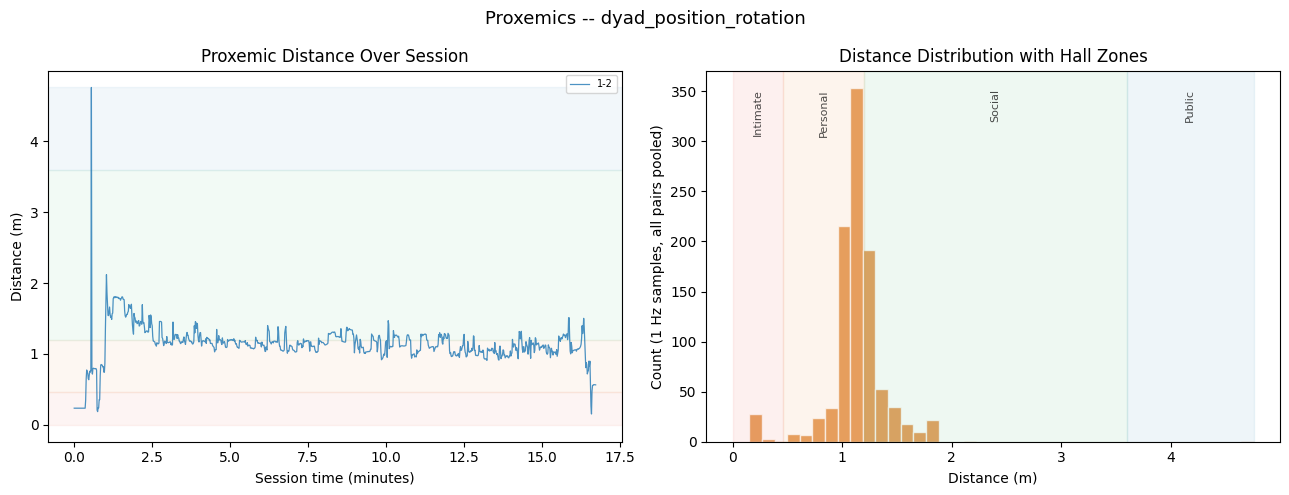

In [10]:
zone_bands = [(0, 0.46, '#e74c3c', 'Intimate'), (0.46, 1.2, '#e67e22', 'Personal'),
              (1.2, 3.6, '#27ae60', 'Social'), (3.6, max(proxemics['distance_m'].max(), 4.0), '#2980b9', 'Public')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for lo, hi, color, label in zone_bands:
    ax.axhspan(lo, hi, color=color, alpha=0.06)
for i, (pa, pb) in enumerate(all_pairs(participants)):
    sub = proxemics[(proxemics.participant_a == pa) & (proxemics.participant_b == pb)]
    ax.plot(sub['session_time_s'] / 60.0, sub['distance_m'], linewidth=0.9,
            color=plt.get_cmap('tab10')(i % 10), alpha=0.8, label=f'{pa}-{pb}')
ax.set_xlabel('Session time (minutes)'); ax.set_ylabel('Distance (m)')
ax.set_title('Proxemic Distance Over Session')
if len(all_pairs(participants)) <= 8:
    ax.legend(fontsize=7, ncol=2)

ax2 = axes[1]
ax2.hist(proxemics['distance_m'].dropna(), bins=40, color=ORANGE, alpha=0.8, edgecolor='white')
for lo, hi, color, label in zone_bands:
    ax2.axvspan(lo, hi, color=color, alpha=0.08)
    ax2.text((lo + min(hi, proxemics['distance_m'].max())) / 2, ax2.get_ylim()[1] * 0.95, label,
              ha='center', va='top', fontsize=8, rotation=90, alpha=0.7)
ax2.set_xlabel('Distance (m)'); ax2.set_ylabel('Count (1 Hz samples, all pairs pooled)')
ax2.set_title('Distance Distribution with Hall Zones')

plt.suptitle(f'Proxemics -- {SELECTED}', fontsize=13)
plt.tight_layout()
plt.savefig(f'proxemics_{SELECTED}.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary -- selected dataset

In [1]:
print(f"=== Summary: {SELECTED} ({df['source_format'].iloc[0]}, {len(participants)} participants) ===")
if len(direction_sync):
    print(f"Social synchrony:    mean aggregate direction-sync score={direction_sync['corr_agg'].mean():.3f}")
else:
    print("Social synchrony:    n/a (no facing-direction data in this format/session)")
if len(hand_tracked) >= 2:
    print(f"Hand synchrony:      mean={hand_sync['synchrony'].mean():.3f}  (0.5 = chance)")
else:
    print("Hand synchrony:      n/a (no hand tracking in this format/session)")
print(f"Proxemics:           mean distance={proxemics['distance_m'].mean():.3f} m  "
      + '  '.join(f'{k}={v:.1f}%' for k, v in overall_zb.items()))

=== Summary: dyad_position_rotation (position_rotation_csv, 2 participants) ===
Social synchrony:    n/a (no facing-direction data in this format/session)
Hand synchrony:      mean=0.513  (0.5 = chance)
Proxemics:           mean distance=1.137 m  intimate=3.1%  personal=66.6%  social=30.2%  public=0.1%


## 8. Run the same pipeline across every example dataset

The point of the unified loader/analysis layer: this loop runs the *identical*
code path against all four format families and produces one comparison
table, with no per-format branching.

In [1]:
def run_pipeline(name, spec):
    d = load_session(**spec, session_id=name)
    ppl = sorted(d['participant_id'].unique())
    hz = round(estimate_native_hz(d))
    res = resample_session(d, rate_hz=hz)
    res_1hz = resample_session(d, rate_hz=PROXEMICS_HZ)
    hands = [p for p in ppl if has_hand_data(res[p])]
    dirs = [p for p in ppl if has_direction_data(res[p])]

    ds = direction_sync_all_pairs(res) if len(dirs) >= 2 else pd.DataFrame()
    hs = hand_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S) if len(hands) >= 2 else None
    px = compute_proxemics(res_1hz)

    return {
        'dataset': name,
        'format': d['source_format'].iloc[0],
        'n_participants': len(ppl),
        'n_pairs': len(all_pairs(ppl)),
        'duration_s': round(d['t_s'].max() - d['t_s'].min(), 1),
        'native_hz': hz,
        'direction_sync_mean_agg': round(ds['corr_agg'].mean(), 3) if len(ds) else np.nan,
        'hand_sync_mean': round(hs['synchrony'].mean(), 3) if hs is not None and len(hs) else np.nan,
        'hand_tracking': bool(hands),
        'direction_tracking': bool(len(dirs) >= 2),
        'proxemics_mean_m': round(px['distance_m'].mean(), 3) if len(px) else np.nan,
    }


comparison = pd.DataFrame([run_pipeline(name, spec) for name, spec in DATASETS.items()])
comparison


                  dataset                 format  n_participants  n_pairs  duration_s  native_hz  direction_sync_mean_agg  hand_sync_mean  hand_tracking  \
0  dyad_position_rotation  position_rotation_csv               2        1      1003.8         29                      NaN           0.513           True   
1           quest_7person              quest_csv               7       21      2455.5         30                    0.008             NaN          False   
2             fashion_pkl               pkl_long               2        1      1053.5         10                   -0.050             NaN          False   
3             conflab_pkl               pkl_long               3        3       665.0         30                   -0.027             NaN          False   

   direction_tracking  proxemics_mean_m  
0               False             1.137  
1                True             4.012  
2                True             2.198  
3                True             1.790  